In [1]:
import pandas as pd
# Replace 'your_file.csv' with your actual file path
df = pd.read_csv('BotnetFull.csv')
# Show the first 5 rows to verify

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8580 - loss: 0.6822 - val_accuracy: 0.9675 - val_loss: 0.2111
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9773 - loss: 0.1668 - val_accuracy: 0.9747 - val_loss: 0.1481
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9806 - loss: 0.1222 - val_accuracy: 0.9747 - val_loss: 0.1305
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9853 - loss: 0.1052 - val_accuracy: 0.9747 - val_loss: 0.1316
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9805 - loss: 0.0992 - val_accuracy: 0.9747 - val_loss: 0.1225
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9814 - loss: 0.0948 - val_accuracy: 0.9783 - val_loss: 0.1140
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9816 - loss: 0.0943 - val_accuracy: 0.9747 - val_loss: 0.1114
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9874 - loss: 0.0793 - val_accuracy: 0.9747 - val_loss: 0.1103


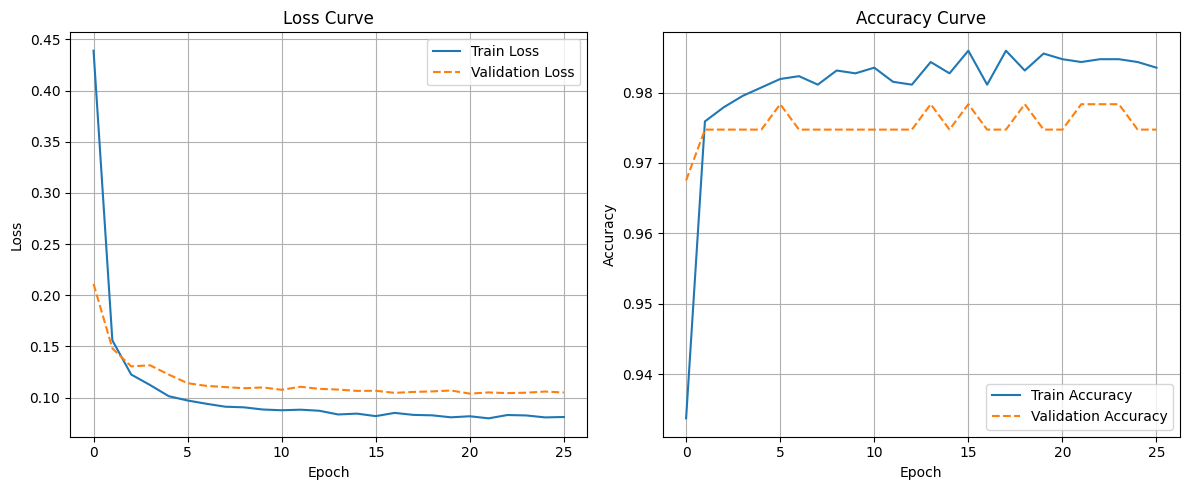

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2

# Step 1: Load and clean the dataset
df = pd.read_csv("BotnetFull.csv")
df.columns = df.columns.str.replace('\n', '', regex=True).str.strip()

# Step 2: Split features and label (last column is label)
X = df.iloc[:, :-1].values  # First 455 columns = features
y = df.iloc[:, -1].values   # Last column = label (0 or 1)

# # Step 3: Normalize features
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# Step 4: Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5: Define the MLP model
model = Sequential([
    Dense(454, input_shape=(455,), activation='relu',kernel_regularizer=l2(0.001)),  # Hidden layer
    Dropout(0.4),  # Dropout layer (50% dropout rate)
    Dense(1, activation='sigmoid',kernel_regularizer=l2(0.001))                      # Output layer
])

# Step 6: Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Step 7: Add Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Step 8: Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Step 9: Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# Step 10: Plot loss and accuracy curves
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 11: Save the model
# model.save("botnet_original_arch_dropout.h5")
# print("✅ Model saved as 'botnet_mlp_model_keras.h5'")



one thing i can obsereve that validation error has decreased due to l2 regularization,
but test accuracy is still not exceeding 98%!!!   so now i have used all techniques
to avoid overfitting which are

    1. dropout layer
    2. early Stopping
    3. l2 regularization

also to avoid vanishing gradient problem , i have

  1. changed avitvation function of hiddden layer from sigmoid to relu.
  2. shoud i  try batch normalization?

also i should try doing

1.cross validation,
2.  feature extraction,
3.  feature selection,
4. feature reduction,
5. optimizers: it only speeds up the training process, doesnt inc acc
6. try to decrease no of neurons in the 1st hidden layer


trying cross validation to make sure accuracy results on test data is robust

In [ ]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.regularizers import l2  # Optional, if you're using L2

# Step 1: Load and clean the dataset
df = pd.read_csv("BotnetFull.csv")
df.columns = df.columns.str.replace('\n', '', regex=True).str.strip()

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Step 2: Define a function to create the model
def create_model():
    model = Sequential([
        Dense(454, input_shape=(455,), activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.2),
        Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001))
    ])
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Step 3: K-Fold Cross Validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
acc_per_fold = []
loss_per_fold = []

for train_idx, val_idx in kfold.split(X, y):
    print(f"\n🔁 Fold {fold_no}")

    # Split data
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Create and train model
    model = create_model()
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate model
    scores = model.evaluate(X_val, y_val, verbose=0)
    print(f"✅ Fold {fold_no} - Loss: {scores[0]:.4f} - Accuracy: {scores[1]*100:.2f}%")
    acc_per_fold.append(scores[1] * 100)
    loss_per_fold.append(scores[0])
    fold_no += 1

# Step 4: Summary
print("\n📊 Cross-validation results:")
print(f"Average Accuracy: {np.mean(acc_per_fold):.2f}% (+/- {np.std(acc_per_fold):.2f})")
print(f"Average Loss: {np.mean(loss_per_fold):.4f}")



🔁 Fold 1


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 1 - Loss: 0.0933 - Accuracy: 97.98%

🔁 Fold 2
✅ Fold 2 - Loss: 0.0911 - Accuracy: 97.98%

🔁 Fold 3
✅ Fold 3 - Loss: 0.0897 - Accuracy: 97.98%

🔁 Fold 4
✅ Fold 4 - Loss: 0.0993 - Accuracy: 96.96%

🔁 Fold 5
✅ Fold 5 - Loss: 0.0949 - Accuracy: 97.54%

📊 Cross-validation results:
Average Accuracy: 97.69% (+/- 0.40)
Average Loss: 0.0937


Now will try doing BatchNormalization after relu activation function

> Add blockquote



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8724 - loss: 0.5539 - val_accuracy: 0.9675 - val_loss: 0.3958
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9789 - loss: 0.1632 - val_accuracy: 0.9747 - val_loss: 0.2806
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9842 - loss: 0.1239 - val_accuracy: 0.9783 - val_loss: 0.2118
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9821 - loss: 0.1093 - val_accuracy: 0.9819 - val_loss: 0.1573
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9877 - loss: 0.0926 - val_accuracy: 0.9819 - val_loss: 0.1274
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9881 - loss: 0.0764 - val_accuracy: 0.9747 - val_loss: 0.1168
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9873 - loss: 0.0766 - val_accuracy: 0.9819 - val_loss: 0.1100
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9950 - loss: 0.0611 - val_accuracy: 0.9783 - val_loss

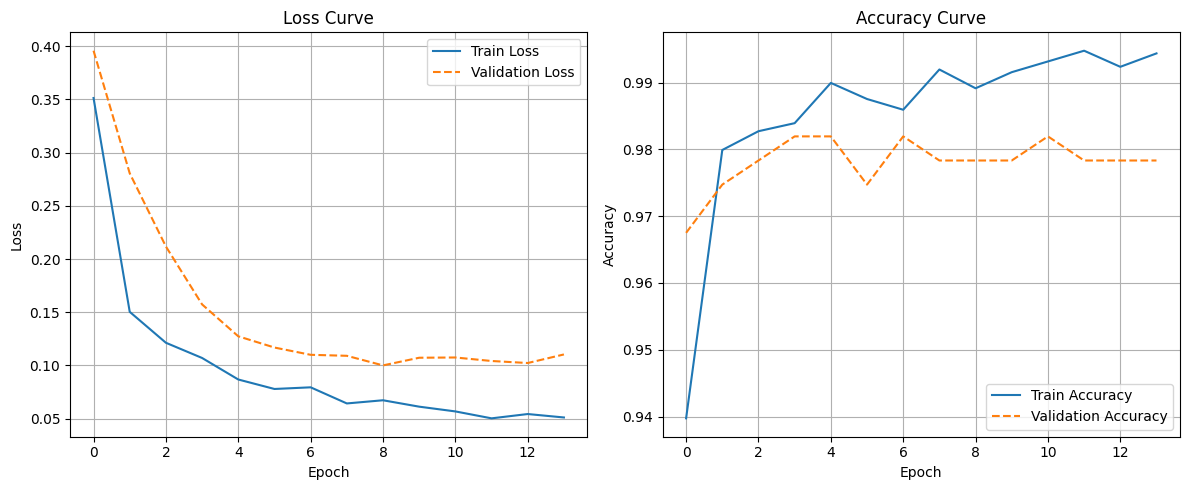

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2

# Step 1: Load and clean the dataset
df = pd.read_csv("BotnetFull.csv")
df.columns = df.columns.str.replace('\n', '', regex=True).str.strip()

# Step 2: Split features and label (last column is label)
X = df.iloc[:, :-1].values  # First 455 columns = features
y = df.iloc[:, -1].values   # Last column = label (0 or 1)

# # Step 3: Normalize features
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# Step 4: Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5: Define the MLP model
model = Sequential([
    Dense(454, input_shape=(455,), activation='relu',kernel_regularizer=l2(0.001)),  # Hidden layer
    Dropout(0.4),  # Dropout layer (50% dropout rate)
    BatchNormalization(),
    Dense(1, activation='sigmoid',kernel_regularizer=l2(0.001))                      # Output layer
])

# Step 6: Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Step 7: Add Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Step 8: Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Step 9: Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# Step 10: Plot loss and accuracy curves
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 11: Save the model
# model.save("botnet_original_arch_dropout.h5")
# print("✅ Model saved as 'botnet_mlp_model_keras.h5'")

